In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import platform
import random
from collections import OrderedDict
import jupyter_client
import jupyterlab
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import scipy
import seaborn as sns
from IPython.display import display
from notebook import __version__ as nb_ver

np.set_printoptions(precision=60, threshold=20, edgeitems=8, suppress=True, linewidth=999, sign=' ', floatmode='maxprec_equal')
SEED = 1010336213
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 3)
pd.set_option('display.html.border', 0)
pd.set_option('mode.chained_assignment', 'raise')
pd.set_option('display.colheader_justify', 'center')

plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 16.0, 10.0
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['image.interpolation'] = 'None'
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['savefig.bbox'] = 'tight'

sns.set()
sns.set(font_scale=0.8)
plt.style.use("dark_background")
sns.set_context(rc={'patch.linewidth': 0.0})
sns.set_style({
    'axes.axisbelow': False,
    'grid.color': '#ccc',
    'grid.alpha': 0.33,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'axes.facecolor': '#111',
    'axes.edgecolor': '#ccc',
    'axes.grid': True,
    'axes.labelcolor': '#ccc',
    'figure.facecolor': '#111',
    'text.color': '#ccc',
    'xtick.color': '#ccc',
    'ytick.color': '#ccc',
    'patch.edgecolor': '#ccc',
})
sns.set_palette("pastel")

plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'both'
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['grid.alpha'] = 0.33
plt.rcParams['grid.color'] = '#ccc'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Fixed random seed for better reproducibility
SEED = 4146516932
random.seed(SEED)
np.random.seed(SEED)

versions = pd.DataFrame.from_dict(OrderedDict([
    ('Operating system', ' '.join([platform.system(), platform.processor()])),
    ('Python', platform.python_version()),
    ('Jupyter', jupyter_client.__version__),
    ('Jupyter Notebook', nb_ver),
    ('Jupyter Lab', jupyterlab.__version__),
    ('Matplotlib', matplotlib.__version__),
    ('Seaborn', sns.__version__),
    ('Numpy', np.__version__),
    ('Pandas', pd.__version__),
    ('Plotly', plotly.__version__),
    ('SciPy', scipy.__version__),
]), orient='index')
versions.columns = ['Version']
display(versions)

,Version
Operating system,Linux
Python,3.12.11
Jupyter,8.6.3
Jupyter Notebook,7.4.5
Jupyter Lab,4.4.7
Matplotlib,3.10.6
Seaborn,0.13.2
Numpy,2.3.3
Pandas,2.3.2
Plotly,6.3.0


# Exponential Convolution Demonstration

This notebook demonstrates the convolution of two exponential decay functions, comparing numerical integration with the analytical solution.

The exponential functions are defined as:
- $f(x) = ae^{-ax}$ for $x \geq 0$, 0 for $x < 0$  
- $g(x) = be^{-bx}$ for $x \geq 0$, 0 for $x < 0$

Where these represent one-sided exponential decay functions commonly used in probability and signal processing.

## Define Convolution Function

Numerical convolution using discrete integration (Riemann sum):
$(f * g)(x) = \int_{-\infty}^{\infty} f(s)\,g(x-s)\,ds \approx \sum_{i} f(s_i)\,g(x-s_i)\,\Delta s$

For exponential functions with support on $[0, \infty)$, this becomes:
$(f * g)(x) = \int_{0}^{x} f(s)\,g(x-s)\,ds$ for $x \geq 0$

where $\Delta s$ is the grid spacing.

In [1]:
def convolve(f, g, x, s_grid):
    """Numerical convolution using discrete integration (Riemann sum)."""
    ds = s_grid[1] - s_grid[0]  # Grid spacing Δs
    return ds * np.sum(f(s_grid) * g(x - s_grid))

## Exponential Parameters

Define the parameters for our two exponential functions:
- $f(x)$: Decay rate $a = 1$
- $g(x)$: Decay rate $b = 2$

These correspond to the reference document Section 2.

In [2]:
# Exponential parameters - corresponds to convolution.md Section 2
a_f = 1  # parameter 'a' in reference
a_g = 2  # parameter 'b' in reference

## Define Exponential Functions

Both functions are one-sided exponential decay functions:

$$f(x) = \begin{cases}
ae^{-ax}, & x \geq 0 \\
0, & x < 0
\end{cases}$$

$$g(x) = \begin{cases}
be^{-bx}, & x \geq 0 \\
0, & x < 0
\end{cases}$$

In [3]:
def f_exp(x):
    """Exponential decay function: f(x) = a*e^(-ax) for x≥0, 0 for x<0"""
    return a_f * np.exp(-a_f * x) * (x >= 0)

def g_exp(x):
    """Exponential decay function: g(x) = b*e^(-bx) for x≥0, 0 for x<0"""
    return a_g * np.exp(-a_g * x) * (x >= 0)

## Analytical Solution

The convolution of two exponential functions has the analytical form:

$(f * g)(x) = \frac{ab}{a-b}(1-e^{-(a-b)x})e^{-bx}$ for $x \geq 0$ and $a \neq b$

This formula assumes $a > b$. The derivation involves:
1. Setting up the convolution integral: $\int_0^x ae^{-as} \cdot be^{-b(x-s)} ds$
2. Factoring out terms: $abe^{-bx} \int_0^x e^{-(a-b)s} ds$  
3. Evaluating the integral: $\frac{1-e^{-(a-b)x}}{a-b}$

In [4]:
def analytical_result(x):
    """Analytical convolution of two exponentials"""
    if a_f == a_g:
        # Special case: when a = b, result is ab*x*e^(-ax)
        return a_f * a_g * x * np.exp(-a_f * x) * (x >= 0)
    else:
        return (a_f * a_g) / (a_f - a_g) * (1 - np.exp(-(a_f - a_g) * x)) * np.exp(-a_g * x) * (x >= 0)

## Compute Numerical Convolution

Set up grids and compute the convolution numerically.
Note: The integration domain extends slightly into negative values to capture boundary effects.

In [5]:
# Integration grid for convolution (s variable) 
s_grid = np.linspace(-1, 10, 1101)

# Evaluation points for output
x_grid = np.linspace(-1, 10, 1101)

# Compute numerical convolution
numerical_result = []
for x in x_grid:
    numerical_result.append(convolve(f_exp, g_exp, x, s_grid))

numerical_result = np.array(numerical_result)

## Visualization

Compare the numerical and analytical results:

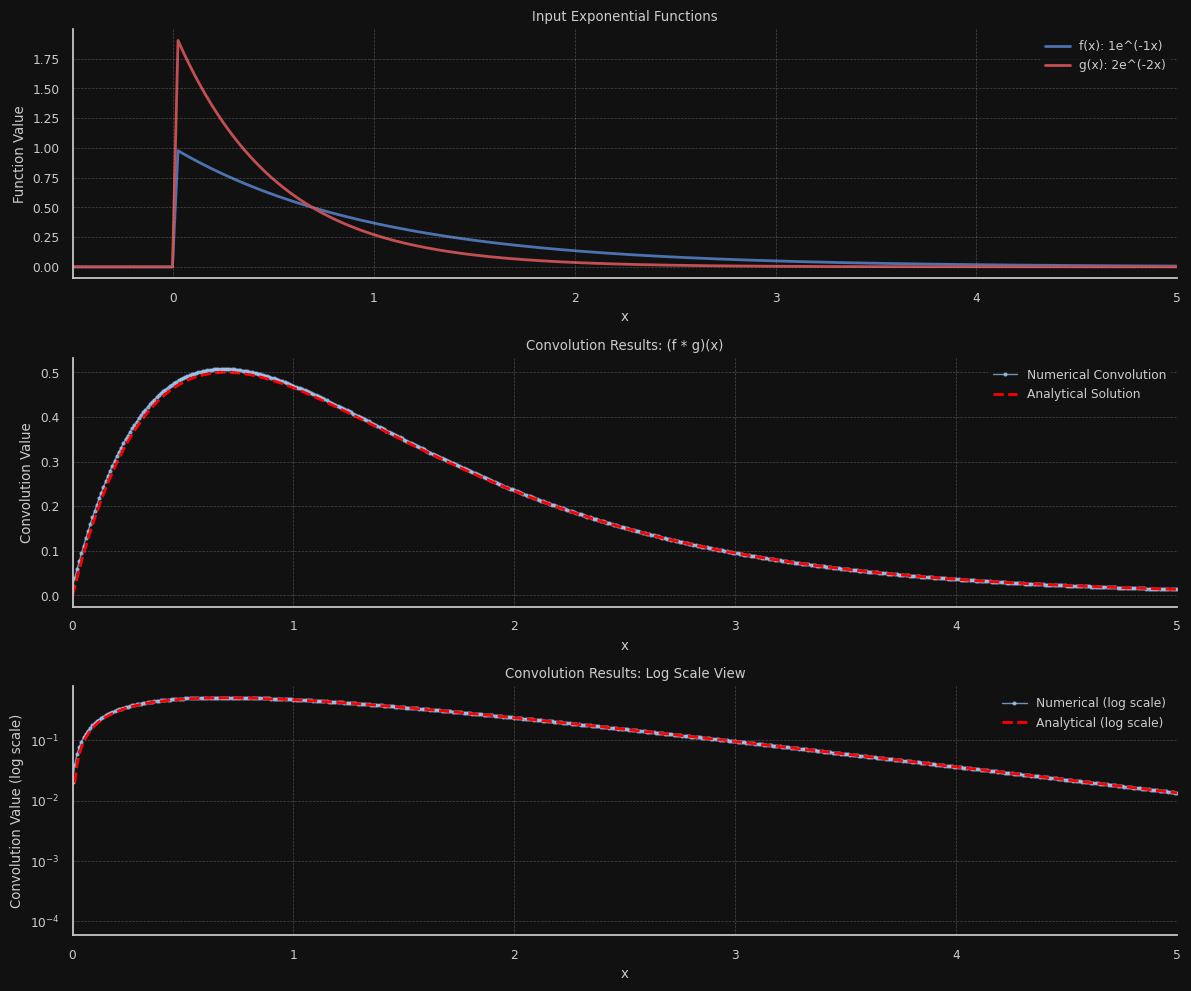

In [6]:
plt.figure(figsize=(12, 10))

# Plot input functions
plt.subplot(3, 1, 1)
x_input = np.linspace(-0.5, 5, 200)
plt.plot(x_input, f_exp(x_input), 'b-', label=f'f(x): {a_f}e^(-{a_f}x)', linewidth=2)
plt.plot(x_input, g_exp(x_input), 'r-', label=f'g(x): {a_g}e^(-{a_g}x)', linewidth=2)
plt.xlabel('x')
plt.ylabel('Function Value')
plt.title('Input Exponential Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 5)

# Plot convolution results
plt.subplot(3, 1, 2)
x_positive = x_grid[x_grid >= 0]
numerical_positive = numerical_result[x_grid >= 0]
plt.plot(x_positive, numerical_positive, 'o-', label='Numerical Convolution', 
         markersize=2, linewidth=1, alpha=0.7)
plt.plot(x_positive, analytical_result(x_positive), '--', label='Analytical Solution', 
         linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('Convolution Value')
plt.title('Convolution Results: (f * g)(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)

# Plot log scale for better visualization of exponential decay
plt.subplot(3, 1, 3)
plt.semilogy(x_positive[numerical_positive > 1e-10], numerical_positive[numerical_positive > 1e-10], 
             'o-', label='Numerical (log scale)', markersize=2, linewidth=1, alpha=0.7)
analytical_positive = analytical_result(x_positive)
plt.semilogy(x_positive[analytical_positive > 1e-10], analytical_positive[analytical_positive > 1e-10], 
             '--', label='Analytical (log scale)', linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('Convolution Value (log scale)')
plt.title('Convolution Results: Log Scale View')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

## Error Analysis

Quantify the difference between numerical and analytical solutions:

Maximum absolute error: 0.02000000
Mean absolute error: 0.00150930
Maximum relative error: 20000000000000.01562500
Mean relative error: 19980019980.03018188


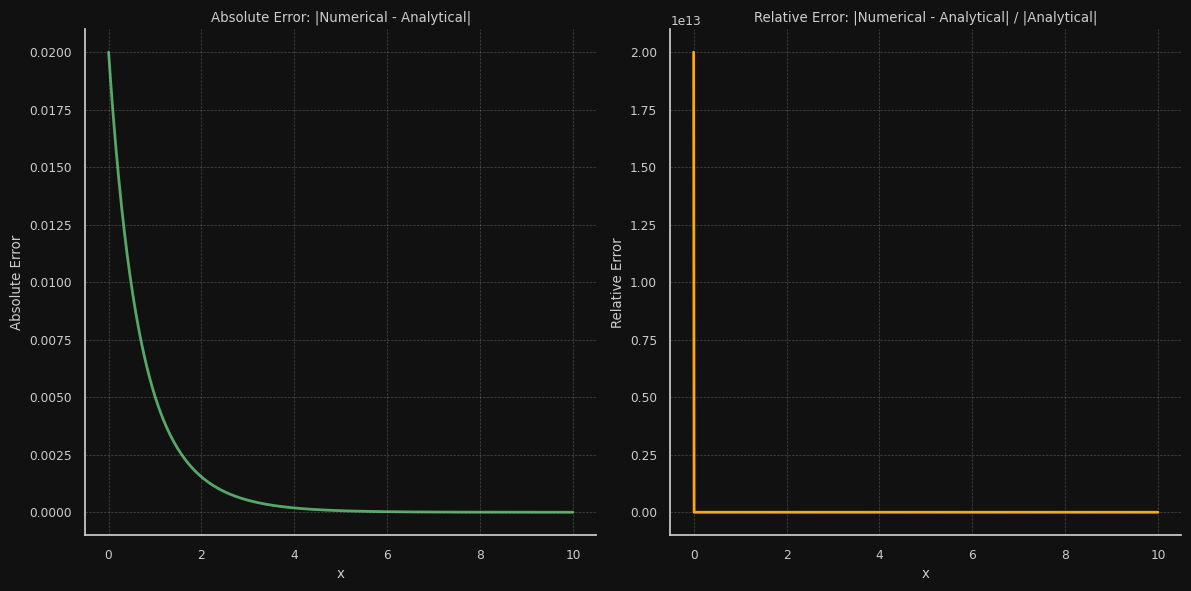

In [7]:
# Focus on positive x values where both functions are non-zero
x_positive = x_grid[x_grid >= 0]
numerical_positive = numerical_result[x_grid >= 0]
analytical_positive = analytical_result(x_positive)

# Calculate error metrics
absolute_error = np.abs(numerical_positive - analytical_positive)
relative_error = absolute_error / (analytical_positive + 1e-15)  # Avoid division by zero

print(f"Maximum absolute error: {np.max(absolute_error):.8f}")
print(f"Mean absolute error: {np.mean(absolute_error):.8f}")
print(f"Maximum relative error: {np.max(relative_error):.8f}")
print(f"Mean relative error: {np.mean(relative_error):.8f}")

# Plot error
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x_positive, absolute_error, 'g-', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Absolute Error: |Numerical - Analytical|')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x_positive, relative_error, 'orange', linewidth=2)
plt.xlabel('x')
plt.ylabel('Relative Error')
plt.title('Relative Error: |Numerical - Analytical| / |Analytical|')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Properties Verification

Verify important properties of the exponential convolution:

In [8]:
# Verify convolution properties
print("=== Exponential Convolution Properties ===")

# 1. Check that convolution is zero for x < 0
negative_indices = x_grid < 0
max_negative = np.max(np.abs(numerical_result[negative_indices]))
print(f"Maximum absolute value for x < 0: {max_negative:.2e} (should be ≈ 0)")

# 2. Check initial value at x = 0
x_zero_idx = np.argmin(np.abs(x_grid))
numerical_at_zero = numerical_result[x_zero_idx]
analytical_at_zero = analytical_result(0)
print(f"Value at x=0: Numerical = {numerical_at_zero:.6f}, Analytical = {analytical_at_zero:.6f}")

# 3. Check asymptotic behavior (should decay exponentially)
x_large = x_positive[-50:]  # Last 50 points
numerical_large = numerical_positive[-50:]
analytical_large = analytical_positive[-50:]

# Fit exponential decay to verify rate
log_numerical = np.log(numerical_large[numerical_large > 1e-10])
x_log = x_large[numerical_large > 1e-10]
if len(log_numerical) > 1:
    decay_rate = -np.polyfit(x_log, log_numerical, 1)[0]
    print(f"Measured decay rate: {decay_rate:.3f} (expected ≈ {a_g})")

# 4. Compare peak values and locations
if len(numerical_positive) > 1:
    peak_idx = np.argmax(numerical_positive)
    peak_x = x_positive[peak_idx]
    peak_value_num = numerical_positive[peak_idx]
    peak_value_ana = analytical_result(peak_x)
    print(f"Peak location: x = {peak_x:.3f}")
    print(f"Peak value: Numerical = {peak_value_num:.6f}, Analytical = {peak_value_ana:.6f}")

# 5. Integration check (approximate total area)
dx = x_positive[1] - x_positive[0]
total_area_numerical = np.sum(numerical_positive) * dx
total_area_analytical = np.sum(analytical_positive) * dx
print(f"Total area: Numerical = {total_area_numerical:.6f}, Analytical = {total_area_analytical:.6f}")

=== Exponential Convolution Properties ===
Maximum absolute value for x < 0: 0.00e+00 (should be ≈ 0)
Value at x=0: Numerical = 0.020000, Analytical = -0.000000
Measured decay rate: 1.000 (expected ≈ 2)
Peak location: x = 0.680
Peak value: Numerical = 0.507549, Analytical = 0.499912
Total area: Numerical = 1.015001, Analytical = 0.999893


## Mathematical Insight

The exponential convolution demonstrates several important mathematical concepts:

1. **Causal Functions**: Both input functions are zero for $x < 0$, making this a causal system
2. **Exponential Decay**: The result maintains exponential decay with rate determined by the slower-decaying input
3. **Impulse Response**: This type of convolution is fundamental in linear systems theory
4. **Laplace Transform**: The analytical solution can be derived using Laplace transforms:
   - $\mathcal{L}\{ae^{-ax}\} = \frac{a}{s+a}$
   - $\mathcal{L}\{be^{-bx}\} = \frac{b}{s+b}$
   - $\mathcal{L}\{(f*g)(x)\} = \frac{a}{s+a} \cdot \frac{b}{s+b} = \frac{ab}{(s+a)(s+b)}$

The partial fraction decomposition yields the time-domain result.

=== Effect of Parameter Changes ===


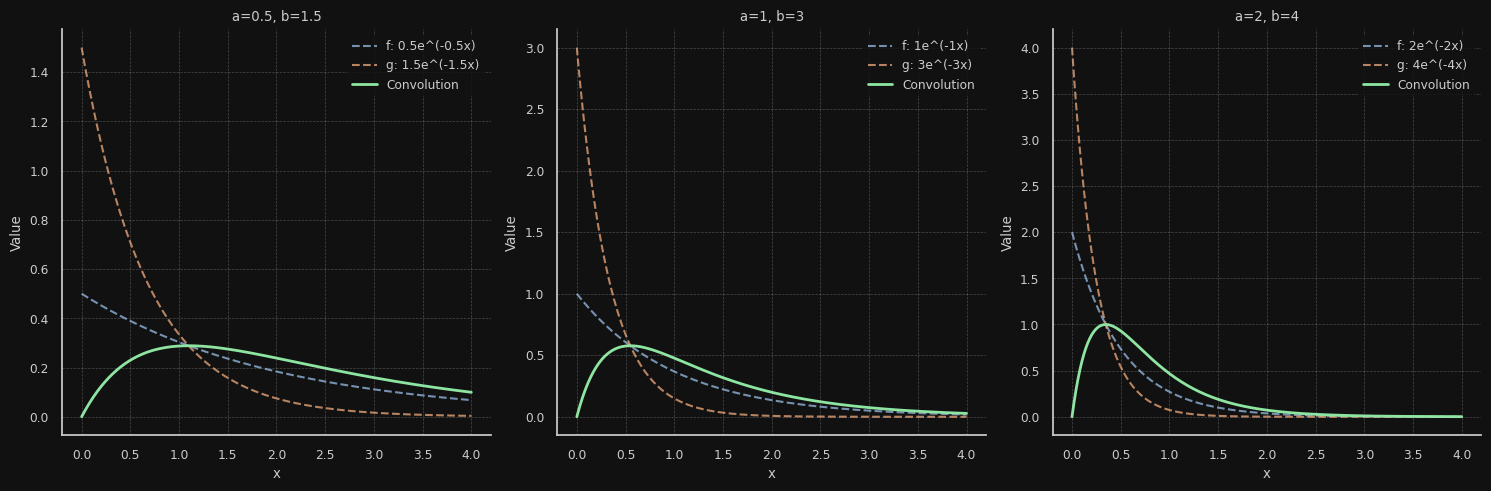

In [9]:
# Demonstrate the relationship with different parameter values
print("=== Effect of Parameter Changes ===")

# Test with different decay rates
test_params = [(0.5, 1.5), (1, 3), (2, 4)]

plt.figure(figsize=(15, 5))

for i, (a, b) in enumerate(test_params):
    plt.subplot(1, 3, i+1)
    
    # Define test functions
    f_test = lambda x: a * np.exp(-a * x) * (x >= 0)
    g_test = lambda x: b * np.exp(-b * x) * (x >= 0)
    
    # Analytical result
    analytical_test = lambda x: (a * b) / (a - b) * (1 - np.exp(-(a - b) * x)) * np.exp(-b * x) * (x >= 0)
    
    x_test = np.linspace(0, 4, 200)
    
    plt.plot(x_test, f_test(x_test), '--', label=f'f: {a}e^(-{a}x)', alpha=0.7)
    plt.plot(x_test, g_test(x_test), '--', label=f'g: {b}e^(-{b}x)', alpha=0.7)
    plt.plot(x_test, analytical_test(x_test), '-', label=f'Convolution', linewidth=2)
    
    plt.title(f'a={a}, b={b}')
    plt.xlabel('x')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()